Epoch 1/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9512 - loss: 0.1627 - val_accuracy: 0.9858 - val_loss: 0.0441
Epoch 2/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9855 - loss: 0.0467 - val_accuracy: 0.9863 - val_loss: 0.0412
Epoch 3/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9903 - loss: 0.0309 - val_accuracy: 0.9891 - val_loss: 0.0335
Epoch 4/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9926 - loss: 0.0224 - val_accuracy: 0.9894 - val_loss: 0.0344
Epoch 5/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9948 - loss: 0.0164 - val_accuracy: 0.9890 - val_loss: 0.0328
Epoch 6/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9955 - loss: 0.0143 - val_accuracy: 0.9901 - val_loss: 0.0320
Epoch 7/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9969 - loss: 0.0099 - val_accuracy: 0.9907 - val_loss: 0.0327
Epoch 8/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9966 - loss: 0.0102 - val_acc

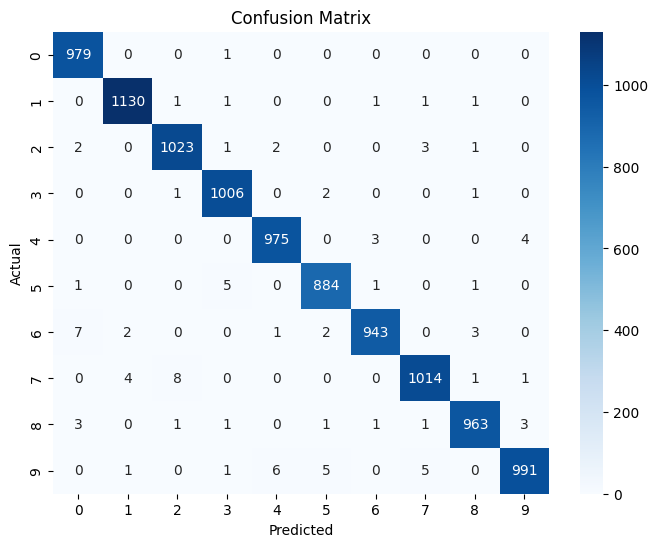

Loss : 0.03470190241932869
Accuracy : 0.9908000230789185


In [5]:
## Deep Learning Lab 2 - Build a Multiclass classifier using CNN (MNIST)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from sklearn.metrics import confusion_matrix

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Image dimensions
img_rows, img_cols = 28, 28

# Reshape based on backend format
if keras.backend.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

# Convert to float and normalize (ONLY ONCE)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Input layer
inpx = Input(shape=input_shape)

# CNN Layers
x = Conv2D(32, (3, 3), activation='relu')(inpx)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)   # changed from sigmoid → relu
output = Dense(10, activation='softmax')(x)

# Model
model = Model(inputs=inpx, outputs=output)

# Compile (Adadelta → Adam for better learning)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
model.fit(x_train, y_train, epochs=12, batch_size=128, validation_data=(x_test, y_test))

# Evaluate
score = model.evaluate(x_test, y_test, verbose=0)

# Predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted") 
plt.ylabel("Actual")
plt.show()

# Results
print('Loss :', score[0])
print('Accuracy :', score[1])